# Submission Pertama: Menyelesaikan Permasalahan Human Resources - Jaya Jaya Maju

- Nama: M Nafis Fakhrudin
- Email: nafisfakhru@gmail.com
- Id Dicoding: nafis_fakhru

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import joblib

pd.set_option('display.max_columns', None)

### Menyiapkan data yang akan diguankan

In [2]:
df = pd.read_csv("data/employee_data.csv")
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,4,Male,88,3,1,Human Resources,2,Married,2991,5224,0,Y,Yes,11,3,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,1,Female,61,1,2,Healthcare Representative,2,Married,4777,14382,5,Y,No,15,3,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,1,Male,34,3,1,Research Scientist,3,Married,2461,10332,9,Y,Yes,12,3,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,3,Female,77,3,4,Sales Executive,2,Married,13525,14864,5,Y,No,14,3,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,3,Female,98,3,1,Research Scientist,3,Married,2001,12549,2,Y,No,14,3,2,80,3,20,2,3,5,3,0,2


## Business Understanding

### Business problem

Jaya Jaya Maju perlu memahami faktor yang berkaitan dengan employee attrition agar HR dapat memprioritaskan tindakan retention. Dari data berlabel, attrition rate perusahaan adalah 16,92%.

### Project scope

Proyek ini mencakup business understanding, data understanding, EDA, preprocessing, perbandingan model klasifikasi, penyimpanan pipeline model, penyiapan data dashboard Metabase, dan dokumentasi panduan dashboard. Dashboard akan dibuat manual di Metabase; deployment Docker tidak termasuk scope.

### Preparation

Data tanpa label dipisahkan dari data berlabel. Data tanpa label tidak digunakan untuk training. Seluruh preprocessing model dibungkus dalam sklearn pipeline agar dapat digunakan kembali oleh script prediksi.

### Tujuan proyek

1. Mengidentifikasi kelompok karyawan dengan attrition rate tinggi.
2. Membandingkan Logistic Regression sebagai baseline dengan Random Forest Classifier.
3. Memilih model berdasarkan F1-score dan recall kelas attrition.
4. Menyediakan dataset bersih dan dokumentasi rancangan dashboard untuk membantu monitoring HR.

### Pertanyaan bisnis

- Apakah overtime berkaitan dengan attrition yang lebih tinggi?
- Job role, department, marital status, dan business travel mana yang perlu diprioritaskan HR?
- Bagaimana perbedaan age, monthly income, tenure, satisfaction, dan work-life balance antara karyawan yang bertahan dan keluar?
- Bagaimana model dan dashboard dapat digunakan sebagai sinyal awal untuk program retention?

## Data Understanding

In [3]:
df.shape


(1470, 35)

In [4]:
df.columns

Index(['EmployeeId', 'Age', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   str    
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   str    
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   str    
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   str    
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel           

In [6]:
df.isnull().sum()

EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtC

### Insight Missing Value

Berdasarkan hasil pengecekan missing value, hanya kolom `Attrition` yang memiliki data kosong, yaitu sebanyak 412 data. Kolom lainnya tidak memiliki missing value.

Karena `Attrition` merupakan target utama dalam proyek ini, data dengan nilai `Attrition` kosong tidak dapat langsung digunakan untuk proses training model machine learning. Oleh karena itu, pada tahap data preparation, data akan dipisahkan menjadi data yang memiliki label attrition dan data yang belum memiliki label.

In [7]:
missing_attrition = df['Attrition'].isnull().sum()
total_data = len(df)
missing_percentage = missing_attrition / total_data * 100

print(f"Jumlah missing value pada Attrition: {missing_attrition}")
print(f"Persentase missing value pada Attrition: {missing_percentage:.2f}%")

Jumlah missing value pada Attrition: 412
Persentase missing value pada Attrition: 28.03%


In [8]:
attrition_counts = df['Attrition'].value_counts(dropna=True)
attrition_rate = attrition_counts[1.0] / attrition_counts.sum() * 100

print("Distribusi Attrition:")
print(attrition_counts)
print(f"\nAttrition Rate: {attrition_rate:.2f}%")

Distribusi Attrition:
Attrition
0.0    879
1.0    179
Name: count, dtype: int64

Attrition Rate: 16.92%


### Insight Attrition Rate

Berdasarkan data yang memiliki label `Attrition`, terdapat 179 karyawan yang mengalami attrition dan 879 karyawan yang tidak mengalami attrition. Dengan demikian, attrition rate perusahaan adalah sekitar 16,92%.

Nilai ini lebih tinggi dari 10%, sehingga sesuai dengan permasalahan bisnis yang dijelaskan pada latar belakang proyek. Hal ini menunjukkan bahwa perusahaan perlu memahami faktor-faktor yang berkaitan dengan tingginya attrition karyawan.

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [11]:
df['Attrition'].value_counts(dropna=False)

Attrition
0.0    879
NaN    412
1.0    179
Name: count, dtype: int64

In [12]:
df_labeled = df.dropna(subset=['Attrition']).copy()
df_unlabeled = df[df['Attrition'].isnull()].copy()

print("Jumlah data berlabel:", df_labeled.shape)
print("Jumlah data tanpa label:", df_unlabeled.shape)

Jumlah data berlabel: (1058, 35)
Jumlah data tanpa label: (412, 35)


In [13]:
df_labeled['Attrition'] = df_labeled['Attrition'].astype(int)
df_labeled['Attrition'].value_counts()

Attrition
0    879
1    179
Name: count, dtype: int64

In [14]:
categorical_columns = df_labeled.select_dtypes(include=['object', 'string']).columns
numerical_columns = df_labeled.select_dtypes(include=['int64', 'float64']).columns

print("Kolom kategorikal:")
print(categorical_columns.tolist())

print("\nKolom numerik:")
print(numerical_columns.tolist())

Kolom kategorikal:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Kolom numerik:
['EmployeeId', 'Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [15]:
for column in categorical_columns:
    print(f"{column}:")
    print(df_labeled[column].unique())
    print()

BusinessTravel:
<StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

Department:
<StringArray>
['Research & Development', 'Sales', 'Human Resources']
Length: 3, dtype: str

EducationField:
<StringArray>
[         'Medical',    'Life Sciences',        'Marketing',
 'Technical Degree',  'Human Resources',            'Other']
Length: 6, dtype: str

Gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

JobRole:
<StringArray>
['Healthcare Representative',        'Research Scientist',
           'Sales Executive',                   'Manager',
     'Laboratory Technician',         'Research Director',
    'Manufacturing Director',           'Human Resources',
      'Sales Representative']
Length: 9, dtype: str

MaritalStatus:
<StringArray>
['Married', 'Single', 'Divorced']
Length: 3, dtype: str

Over18:
<StringArray>
['Y']
Length: 1, dtype: str

OverTime:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str



## Exploratory Data Analysis

### Attrition Rate Berdasarkan Fitur Kategorikal

Pada tahap ini, dilakukan analisis attrition rate berdasarkan beberapa fitur kategorikal untuk melihat kelompok karyawan mana yang memiliki tingkat attrition lebih tinggi.

In [16]:
def calculate_attrition_rate_by_category(data, column):
    result = data.groupby(column)['Attrition'].agg(['count', 'sum', 'mean']).reset_index()
    result.columns = [column, 'Total Employees', 'Attrition Count', 'Attrition Rate']
    result['Attrition Rate'] = result['Attrition Rate'] * 100
    return result.sort_values(by='Attrition Rate', ascending=False)

for column in categorical_columns:
    print(f"Attrition Rate by {column}")
    display(calculate_attrition_rate_by_category(df_labeled, column))
    print("\n")

Attrition Rate by BusinessTravel

,BusinessTravel,Total Employees,Attrition Count,Attrition Rate
1,Travel_Frequently,205,51,24.878049
2,Travel_Rarely,746,117,15.683646
0,Non-Travel,107,11,10.280374




Attrition Rate by Department


,Department,Total Employees,Attrition Count,Attrition Rate
2,Sales,319,66,20.689655
0,Human Resources,38,6,15.789474
1,Research & Development,701,107,15.263909




Attrition Rate by EducationField


...

,MaritalStatus,Total Employees,Attrition Count,Attrition Rate
2,Single,352,94,26.704545
1,Married,464,62,13.362069
0,Divorced,242,23,9.504132




Attrition Rate by Over18


,Over18,Total Employees,Attrition Count,Attrition Rate
0,Y,1058,179,16.918715




Attrition Rate by OverTime


,OverTime,Total Employees,Attrition Count,Attrition Rate
1,Yes,307,98,31.921824
0,No,751,81,10.785619


### Attrition Berdasarkan OverTime

Visualisasi ini digunakan untuk membandingkan tingkat attrition antara karyawan yang bekerja overtime dan yang tidak.

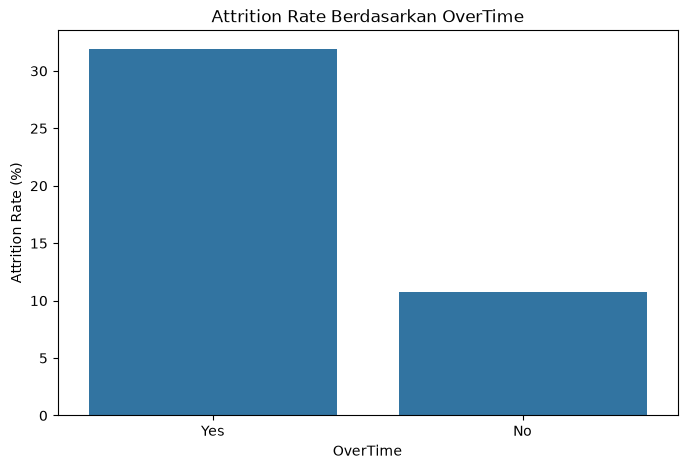

In [17]:
overtime_attrition = calculate_attrition_rate_by_category(df_labeled, 'OverTime')

plt.figure(figsize=(8, 5))
sns.barplot(
    data=overtime_attrition,
    x='OverTime',
    y='Attrition Rate'
)
plt.title('Attrition Rate Berdasarkan OverTime')
plt.xlabel('OverTime')
plt.ylabel('Attrition Rate (%)')
plt.show()

### Attrition Berdasarkan Department

Visualisasi ini digunakan untuk melihat departemen mana yang memiliki attrition rate lebih tinggi.

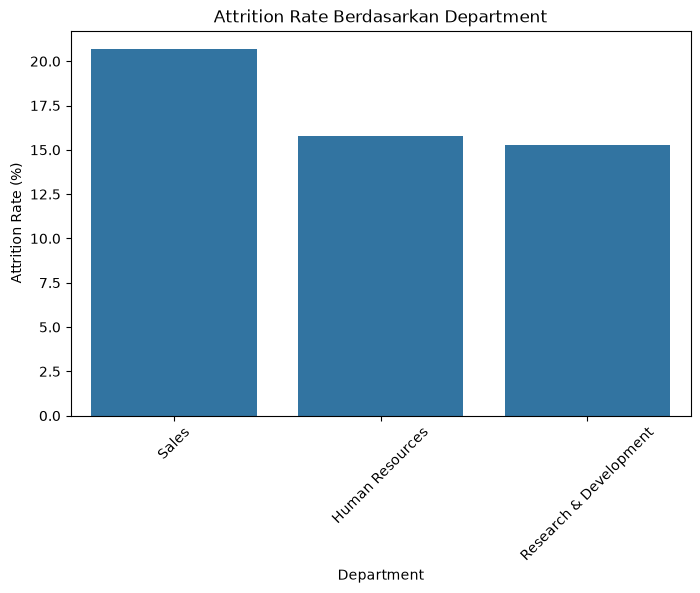

In [18]:
department_attrition = calculate_attrition_rate_by_category(df_labeled, 'Department')

plt.figure(figsize=(8, 5))
sns.barplot(
    data=department_attrition,
    x='Department',
    y='Attrition Rate'
)
plt.title('Attrition Rate Berdasarkan Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.show()

### Attrition Berdasarkan Job Role

Visualisasi ini digunakan untuk melihat posisi pekerjaan yang memiliki attrition rate lebih tinggi.

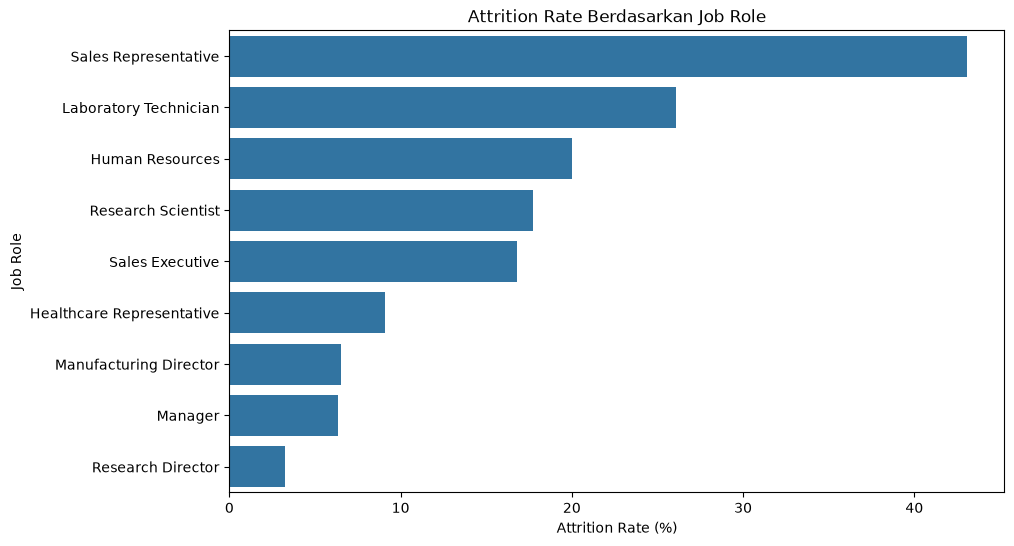

In [19]:
jobrole_attrition = calculate_attrition_rate_by_category(df_labeled, 'JobRole')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=jobrole_attrition,
    y='JobRole',
    x='Attrition Rate'
)
plt.title('Attrition Rate Berdasarkan Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.show()

### Attrition Berdasarkan Marital Status

Visualisasi ini digunakan untuk melihat apakah status pernikahan berkaitan dengan tingkat attrition.

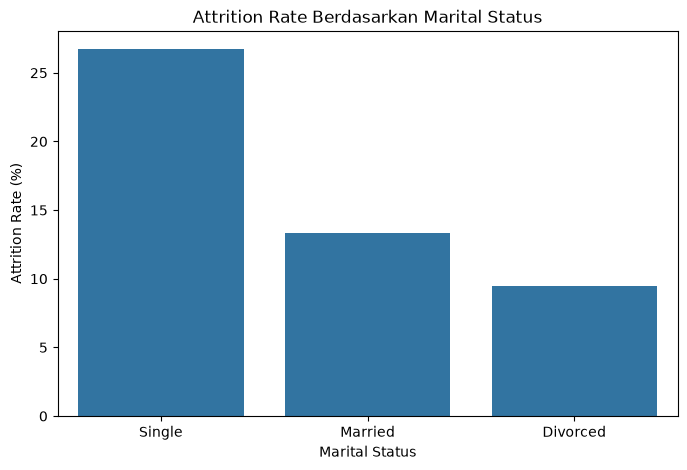

In [20]:
marital_attrition = calculate_attrition_rate_by_category(df_labeled, 'MaritalStatus')

plt.figure(figsize=(8, 5))
sns.barplot(
    data=marital_attrition,
    x='MaritalStatus',
    y='Attrition Rate'
)
plt.title('Attrition Rate Berdasarkan Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Attrition Rate (%)')
plt.show()

### Distribusi Fitur Numerik Berdasarkan Attrition

Analisis ini digunakan untuk membandingkan karakteristik karyawan yang mengalami attrition dan yang tidak berdasarkan beberapa fitur numerik.

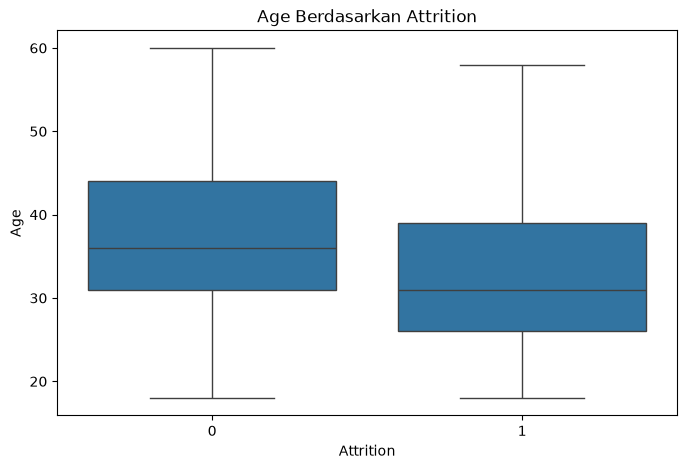

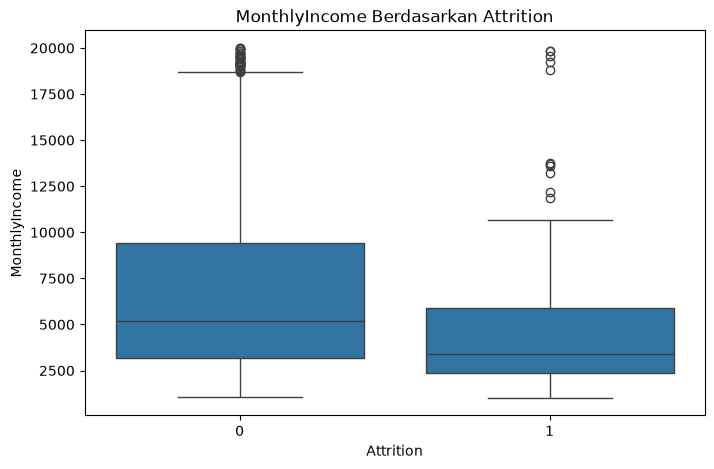

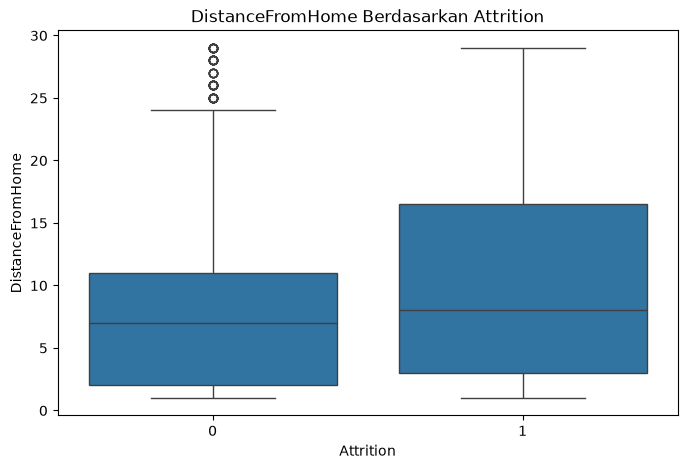

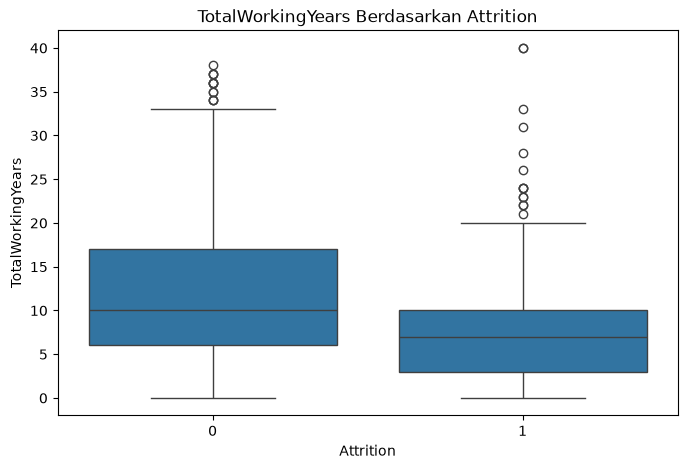

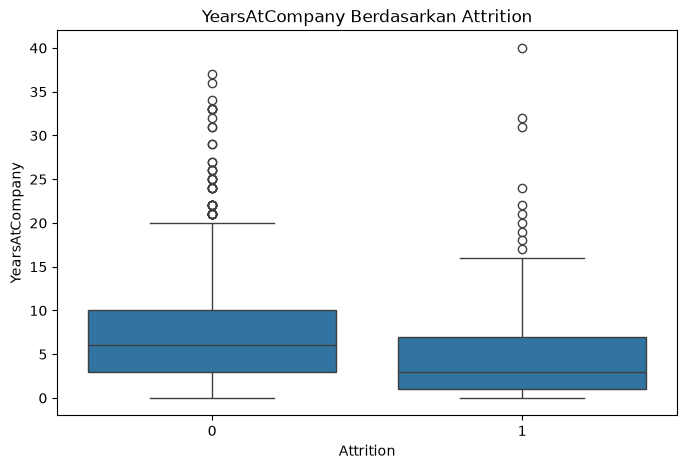

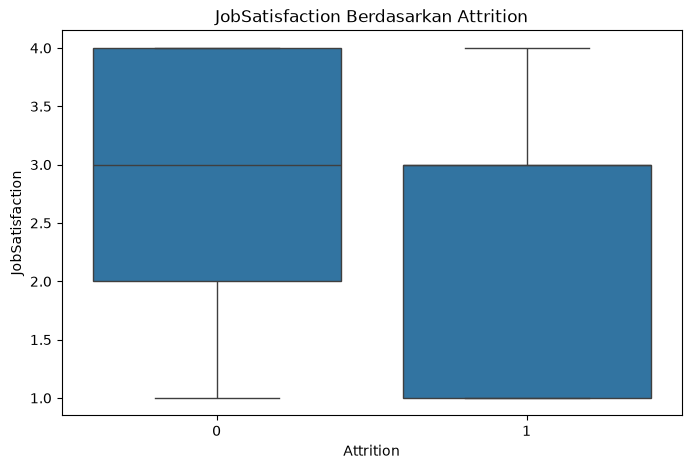

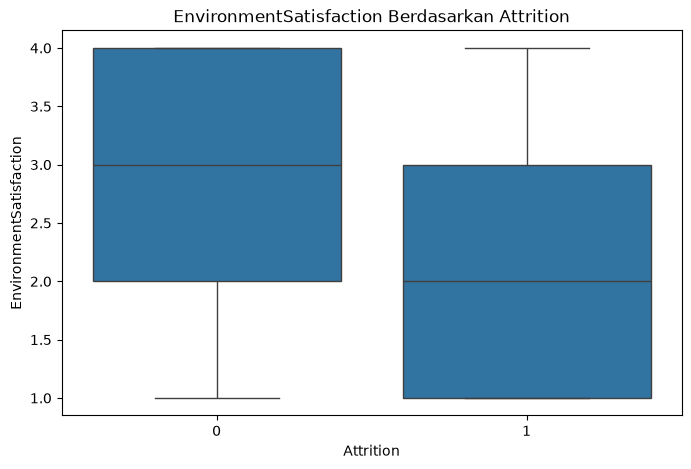

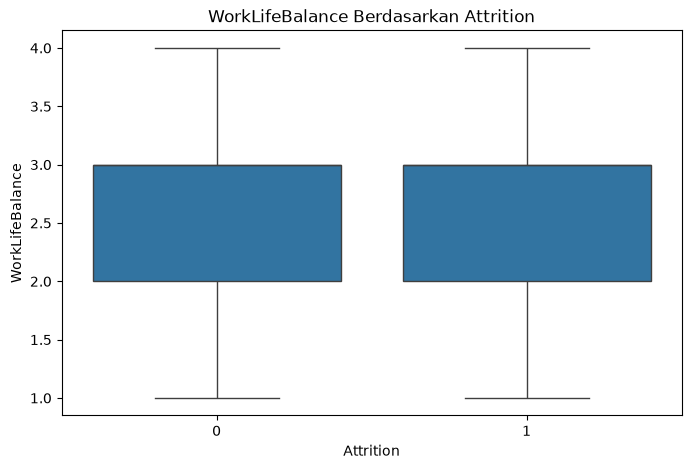

In [21]:
important_numerical_features = [
    'Age',
    'MonthlyIncome',
    'DistanceFromHome',
    'TotalWorkingYears',
    'YearsAtCompany',
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'WorkLifeBalance'
]

for column in important_numerical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df_labeled,
        x='Attrition',
        y=column
    )
    plt.title(f'{column} Berdasarkan Attrition')
    plt.xlabel('Attrition')
    plt.ylabel(column)
    plt.show()

### Insight Exploratory Data Analysis

Hasil EDA pada 1.058 data berlabel menunjukkan bahwa attrition tidak tersebar merata. OverTime = Yes memiliki attrition rate 31,92%, hampir tiga kali kelompok OverTime = No (10,79%). Ini memberi sinyal bahwa HR perlu mengevaluasi beban kerja, penjadwalan, dan kompensasi lembur.

Berdasarkan JobRole, Sales Representative memiliki attrition rate tertinggi (43,10%), disusul Laboratory Technician (26,06%). Department Sales juga memiliki attrition rate tertinggi (20,69%). Kedua temuan ini dapat menjadi prioritas untuk stay interview dan retention program, namun tidak boleh dianggap sebagai hubungan sebab-akibat tanpa analisis lanjutan.

Kelompok Single memiliki attrition rate 26,70%, sedangkan Married 13,36% dan Divorced 9,50%. Karyawan yang Travel_Frequently memiliki attrition rate 24,88%, lebih tinggi daripada Travel_Rarely (15,68%) dan Non-Travel (10,28%). HR dapat menggunakan kedua fitur ini untuk segmentasi monitoring, bukan untuk keputusan diskriminatif.

Pada fitur numerik, median MonthlyIncome kelompok attrition adalah 3.388 dibandingkan 5.210 pada kelompok non-attrition. Median Age adalah 31 dibandingkan 36, sedangkan median YearsAtCompany adalah 3 dibandingkan 6. Rata-rata JobSatisfaction, EnvironmentSatisfaction, dan WorkLifeBalance juga lebih rendah pada kelompok attrition; perbedaan paling besar terlihat pada EnvironmentSatisfaction (2,39 vs 2,78). Temuan ini mendukung evaluasi kompensasi, pengalaman kerja, perkembangan karier, dan work-life balance melalui intervensi HR yang terukur.

## Data Preparation / Preprocessing

In [22]:
DROP_COLUMNS = ['EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours']

# Hanya baris dengan target yang digunakan untuk modeling.
df_labeled = df.dropna(subset=['Attrition']).copy()
df_unlabeled = df[df['Attrition'].isnull()].copy()
df_labeled['Attrition'] = df_labeled['Attrition'].astype(int)

X = df_labeled.drop(columns=['Attrition', *DROP_COLUMNS])
y = df_labeled['Attrition']

categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_features = X.select_dtypes(exclude=['object', 'string']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f'Fitur modeling: {X.shape[1]} kolom')
print(f'Data train: {X_train.shape[0]} baris | Data test: {X_test.shape[0]} baris')
print(f'Data tanpa label disimpan terpisah: {df_unlabeled.shape[0]} baris')

Fitur modeling: 30 kolom
Data train: 846 baris | Data test: 212 baris
Data tanpa label disimpan terpisah: 412 baris


## Modeling

In [23]:
def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('numeric', StandardScaler(), numeric_features),
            ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ],
        remainder='drop',
    )

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),
}

trained_models = {}
evaluation_rows = []

for model_name, estimator in models.items():
    pipeline = Pipeline(
        steps=[
            ('preprocessor', build_preprocessor()),
            ('model', estimator),
        ]
    )
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    trained_models[model_name] = pipeline
    evaluation_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1-Score': f1_score(y_test, predictions, zero_division=0),
    })

model_results = (
    pd.DataFrame(evaluation_rows)
    .sort_values(['F1-Score', 'Recall'], ascending=False)
    .reset_index(drop=True)
)
display(model_results.style.format({column: '{:.3f}' for column in ['Accuracy', 'Precision', 'Recall', 'F1-Score']}))

best_model_name = model_results.loc[0, 'Model']
final_model = trained_models[best_model_name]
print(f'Model terbaik berdasarkan F1-score lalu recall: {best_model_name}')

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.863,0.630,0.472,0.540
1,Logistic Regression,0.731,0.360,0.750,0.486


Model terbaik berdasarkan F1-score lalu recall: Random Forest


## Evaluation

Model terpilih: Random Forest
Accuracy : 0.863
Precision: 0.630
Recall   : 0.472
F1-score : 0.540

Classification report:
                 precision    recall  f1-score   support

Tidak Attrition       0.90      0.94      0.92       176
      Attrition       0.63      0.47      0.54        36

       accuracy                           0.86       212
      macro avg       0.76      0.71      0.73       212
   weighted avg       0.85      0.86      0.86       212



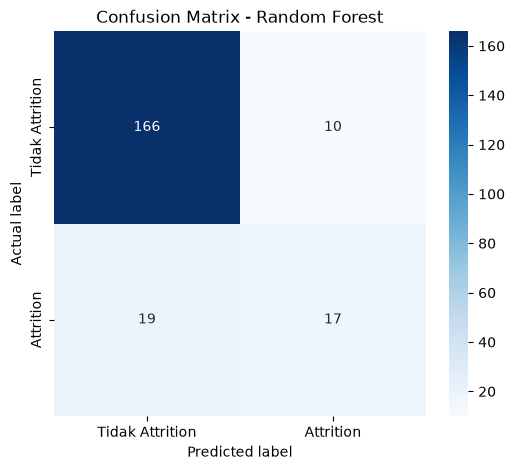

Interpretasi: recall kelas Attrition menunjukkan proporsi karyawan yang benar-benar akan attrition dan berhasil terdeteksi model. Metrik ini penting bagi HR karena false negative dapat membuat karyawan berisiko terlewat dari program retention.
Model pipeline disimpan ke model/attrition_model.pkl


In [24]:
best_predictions = final_model.predict(X_test)

accuracy = accuracy_score(y_test, best_predictions)
precision = precision_score(y_test, best_predictions, zero_division=0)
recall = recall_score(y_test, best_predictions, zero_division=0)
f1 = f1_score(y_test, best_predictions, zero_division=0)

print(f'Model terpilih: {best_model_name}')
print(f'Accuracy : {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall   : {recall:.3f}')
print(f'F1-score : {f1:.3f}')
print('\nClassification report:')
print(classification_report(y_test, best_predictions, target_names=['Tidak Attrition', 'Attrition'], zero_division=0))

cm = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Attrition', 'Attrition'],
    yticklabels=['Tidak Attrition', 'Attrition'],
)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.show()

print('Interpretasi: recall kelas Attrition menunjukkan proporsi karyawan yang benar-benar akan attrition dan berhasil terdeteksi model. Metrik ini penting bagi HR karena false negative dapat membuat karyawan berisiko terlewat dari program retention.')

Path('model').mkdir(exist_ok=True)
joblib.dump(final_model, 'model/attrition_model.pkl')
print('Model pipeline disimpan ke model/attrition_model.pkl')

## Dashboard Data dan Artefak



In [25]:
dashboard_columns = [
    'Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
    'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement',
    'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome',
    'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
]

dashboard_df = df_labeled[dashboard_columns].copy()
dashboard_df.insert(
    2,
    'AttritionLabel',
    dashboard_df['Attrition'].map({0: 'Tidak Attrition', 1: 'Attrition'}),
)
Path('data').mkdir(exist_ok=True)
dashboard_df.to_csv('data/dashboard_employee_data.csv', index=False)

sample_employee = df_unlabeled.drop(columns=['Attrition'], errors='ignore').head(5)
if sample_employee.empty:
    sample_employee = df_labeled.drop(columns=['Attrition'], errors='ignore').head(5)
sample_employee.to_csv('data/sample_employee.csv', index=False)

print(f'Dashboard data disimpan: {dashboard_df.shape[0]} baris, {dashboard_df.shape[1]} kolom')
print(f'Sample input disimpan: {sample_employee.shape[0]} baris')
print('Gunakan data/dashboard_employee_data.csv sebagai sumber data Metabase.')

Dashboard data disimpan: 1058 baris, 28 kolom
Sample input disimpan: 5 baris
Gunakan data/dashboard_employee_data.csv sebagai sumber data Metabase.
